# Creating Word Vectors with word2vec

#### Install Dependencies

In [1]:
import nltk
from nltk.corpus.reader.plaintext import PlaintextCorpusReader
import gensim
from gensim.models.word2vec import Word2Vec
from sklearn.manifold import TSNE
import pandas as pd
from bokeh.io import output_notebook
from bokeh.plotting import show, figure

#### Load Data

In [2]:
corpus_root = 'C:\\Users\\abhir\\Desktop\\Minor Project\\corpus'

In [3]:
corpus = PlaintextCorpusReader(corpus_root, 'eng_40000.txt')

In [4]:
corpus_sents = corpus.sents()

#### Tokenize Text

In [5]:
len(corpus_sents)

35239

In [6]:
corpus_sents[0:4]

[['My', 'mind', 'is', 'like', 'a', 'spring', 'trap', '...'],
 ['So',
  'you',
  "'",
  're',
  'gonna',
  'kill',
  'Colonel',
  'Vickers',
  'to',
  'keep',
  'him',
  'quiet',
  ',',
  'huh',
  '?'],
 ['Leo', ',', 'you', 'are', 'a', 'strawberry', 'blonde', '.'],
 ['If',
  'you',
  'don',
  "'",
  't',
  'like',
  'Danny',
  ',',
  'just',
  'tell',
  'her',
  'it',
  "'",
  's',
  'a',
  'bad',
  'idea',
  '.']]

In [7]:
corpus_sents[5]

['I',
 'don',
 "'",
 't',
 'need',
 'you',
 'telling',
 'me',
 'how',
 'to',
 'drive',
 '.']

In [8]:
len(corpus.words())

370028

#### Run word2vec

In [9]:
model = Word2Vec(sentences=corpus_sents, vector_size=64, sg=1, window=8, min_count=5)

In [10]:
model.save('custom_new_english.model')

In [11]:
model = Word2Vec.load('custom_new_english.model')

In [12]:
model.wv['new']

array([ 0.40021673, -0.27860007,  0.0603036 ,  0.09387925,  0.20705187,
       -0.18625857, -0.05217542, -0.01616685, -0.32093072, -0.03925909,
        0.15852386, -0.32752514, -0.19462658, -0.14666522,  0.0950012 ,
        0.39279565, -0.04840489,  0.07721511,  0.01821211,  0.3895783 ,
        0.02432852,  0.29377386,  0.28197166, -0.17497066, -0.08256648,
        0.06723201, -0.13202634, -0.04565515,  0.08419943, -0.02704733,
       -0.04703202,  0.03390488, -0.31104398, -0.29966024, -0.43020794,
        0.05029977,  0.09159018,  0.16665457,  0.00180575,  0.18555889,
        0.12412933, -0.01150897,  0.11306132,  0.02868263,  0.17088364,
        0.15278655,  0.14473702, -0.23935315,  0.20974822,  0.22287834,
        0.11074015, -0.42634338,  0.19998144,  0.27080858,  0.309321  ,
        0.17539991,  0.2157904 , -0.18914314, -0.18423524,  0.10957485,
       -0.03915862, -0.31780192, -0.22949384,  0.07723548], dtype=float32)

In [13]:
model.wv.most_similar('hello')

[('James', 0.9450335502624512),
 ('hi', 0.9444437026977539),
 ('Jerry', 0.9372880458831787),
 ('Elizabeth', 0.9279745221138),
 ('Spanish', 0.9278942942619324),
 ('hey', 0.9275722503662109),
 ('Fletcher', 0.9269611239433289),
 ('Hi', 0.926886260509491),
 ('Doctor', 0.9255222082138062),
 ('Mom', 0.9235742688179016)]

#### Reduce word vector dimensionality with T-SNE

In [14]:
len(model.wv.key_to_index) # Words that met the criteria

4467

In [15]:
X = model.wv[model.wv.key_to_index]

In [16]:
tsne = TSNE()

In [17]:
X_2d = tsne.fit_transform(X)

In [18]:
X_2d[0:5]

array([[ -9.551004,  37.971066],
       [-13.105887,  30.385374],
       [-51.048424,  15.304509],
       [-27.199919,  28.372332],
       [-12.993579, -41.98631 ]], dtype=float32)

In [19]:
coords_df = pd.DataFrame(X_2d, columns=['x', 'y'])
coords_df['token'] = model.wv.key_to_index.keys() # टोकन

In [20]:
coords_df.head()

,x,y,token
0,-9.551004,37.971066,.
1,-13.105887,30.385374,","
2,-51.048424,15.304509,'
3,-27.199919,28.372332,I
4,-12.993579,-41.986309,the


In [21]:
coords_df.to_csv('custom_new_english.csv', index=False)

#### Visulaize 2D representation of word vectors

In [22]:
coords_df = pd.read_csv('custom_new_english.csv')

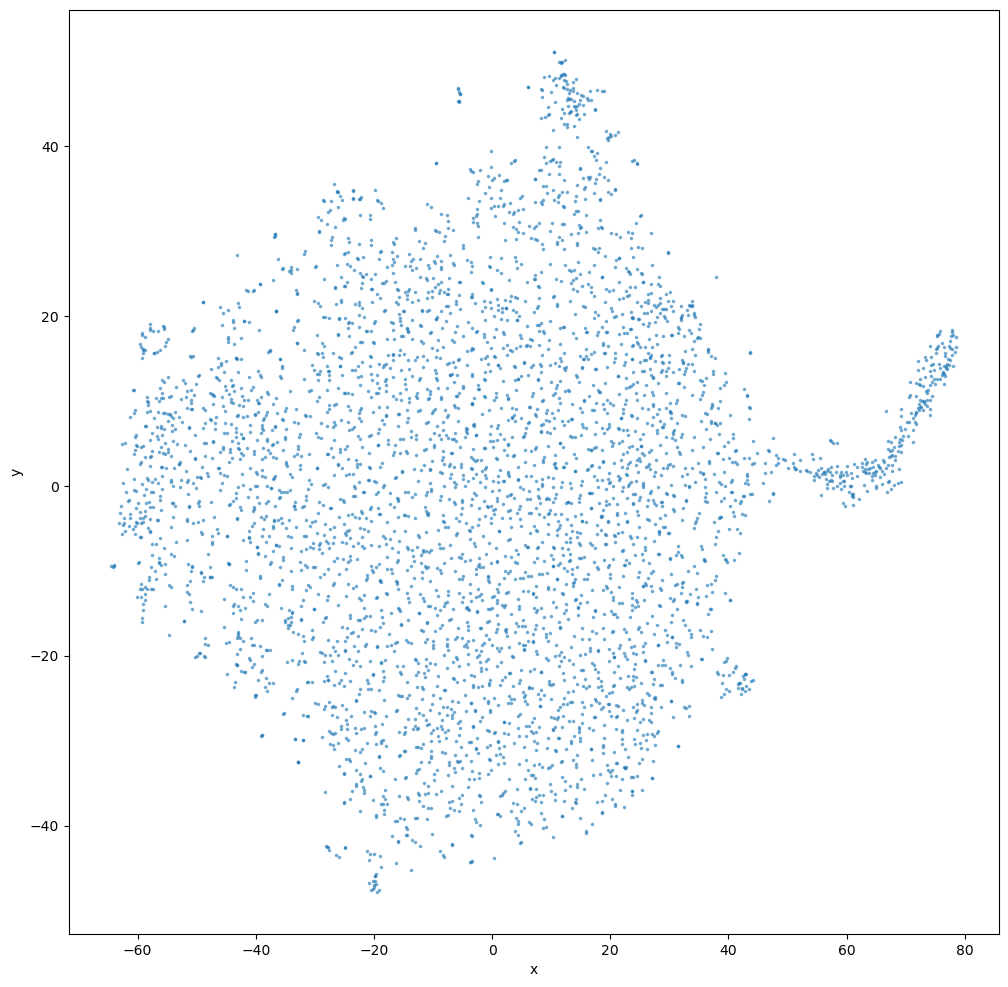

In [23]:
_ = coords_df.plot.scatter('x', 'y', figsize=(12, 12), marker='.', s=10, alpha=0.5)

In [24]:
output_notebook()

Loading BokehJS ...

In [25]:
subset_df = coords_df.sample(n=2500)

In [26]:
p = figure(plot_width=800, plot_height=800)
_ = p.text(x=subset_df.x, y=subset_df.y, text=subset_df.token)

In [27]:
show(p)